In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
filepath=r"C:\Users\Osamah\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [168]:
df=pd.read_csv(filepath)

In [169]:
df.sample(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3561,5998-VVEJY,Male,0,No,No,26,Yes,Yes,Fiber optic,No,...,No,Yes,No,No,Month-to-month,Yes,Electronic check,80.5,2088.8,Yes
3586,8722-NGNBH,Male,0,No,No,5,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,Month-to-month,No,Mailed check,40.0,223.45,Yes
6366,2845-KDHVX,Female,0,Yes,No,64,Yes,No,DSL,No,...,Yes,Yes,No,Yes,Two year,Yes,Mailed check,68.3,4378.8,No


In [170]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [171]:
df.duplicated().sum()

0

In [172]:
df["MultipleLines"].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [173]:
df["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [174]:
df["PaperlessBilling"].unique()

array(['Yes', 'No'], dtype=object)

In [175]:
df=df.drop(columns=["customerID"])

In [176]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [177]:
# Convert Yes/No columns to 1/0

yes_no_columns = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'Churn'
]

for col in yes_no_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [178]:
# Convert gender to 1/0

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [179]:
df["OnlineSecurity"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [180]:
df["OnlineSecurity"] = df['OnlineSecurity'].replace({
    'Yes': 1,
    'No': 0,
    'No internet service': 0
})

C:\Users\Osamah\AppData\Local\Temp\ipykernel_27456\3987344374.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["OnlineSecurity"] = df['OnlineSecurity'].replace({


In [181]:
print(df["DeviceProtection"].unique())
print(df["TechSupport"].unique())
print(df["StreamingMovies"].unique())
print(df["StreamingTV"].unique())

['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']


In [182]:
df["DeviceProtection"] = df['DeviceProtection'].replace({
    'Yes': 1,
    'No': 0,
    'No internet service': 0
})

C:\Users\Osamah\AppData\Local\Temp\ipykernel_27456\2691675864.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DeviceProtection"] = df['DeviceProtection'].replace({


In [183]:
df["TechSupport"] = df['TechSupport'].replace({
    'Yes': 1,
    'No': 0,
    'No internet service': 0
})

C:\Users\Osamah\AppData\Local\Temp\ipykernel_27456\3327888726.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["TechSupport"] = df['TechSupport'].replace({


In [184]:
df["StreamingMovies"] = df['StreamingMovies'].replace({
    'Yes': 1,
    'No': 0,
    'No internet service': 0
})

C:\Users\Osamah\AppData\Local\Temp\ipykernel_27456\1956002181.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["StreamingMovies"] = df['StreamingMovies'].replace({


In [185]:
df["StreamingTV"] = df['StreamingTV'].replace({
    'Yes': 1,
    'No': 0,
    'No internet service': 0
})

C:\Users\Osamah\AppData\Local\Temp\ipykernel_27456\2669530176.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["StreamingTV"] = df['StreamingTV'].replace({


In [186]:
# 1. Check data types
print(df.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity        int64
OnlineBackup         object
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                 int64
dtype: object


In [187]:
# 3. Check duplicate rows
print(df.duplicated().sum())

22


In [188]:
df = df.drop_duplicates()

In [189]:
df.duplicated().sum()

0

In [190]:
#converting TotalCharges to numeric
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [191]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())

float64
11


In [192]:
df=pd.get_dummies(df,drop_first=True)

In [193]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [194]:
from sklearn.model_selection import train_test_split

In [195]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [196]:
X_train.shape

(5616, 25)

In [197]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [198]:
# Logistic Regression
lr = LogisticRegression(
    C=0.5,
    solver='liblinear',
    max_iter=1000,
    penalty='l2'
)


In [199]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=True,
    random_state=42
)

In [200]:
# Decision Tree
Dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    criterion='gini',
    random_state=42
)

In [201]:
X_train = X_train.dropna()
y_train = y_train[X_train.index]

In [202]:
df = df.dropna()

In [203]:
lr.fit(X_train, y_train)

LogisticRegression(C=0.5, max_iter=1000, solver='liblinear')

In [205]:
X_test = X_test.dropna()
y_test = y_test[X_test.index]

In [207]:
lr_pred = lr.predict(X_test)

In [209]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [211]:
print("Accuracy :",accuracy_score(y_test,lr_pred))
print("Precision : ",precision_score(y_test,lr_pred))
print("Recall : ",recall_score(y_test,lr_pred))
print("F1-Score :",f1_score(y_test,lr_pred))

Accuracy : 0.8055555555555556
Precision :  0.6321070234113713
Recall :  0.5369318181818182
F1-Score : 0.5806451612903227


In [214]:
rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [216]:
rf_pred = rf.predict(X_test)

In [218]:
print("Accuracy :",accuracy_score(y_test,rf_pred))
print("Precision : ",precision_score(y_test,rf_pred))
print("Recall : ",recall_score(y_test,rf_pred))
print("F1-Score :",f1_score(y_test,rf_pred))

Accuracy : 0.7970085470085471
Precision :  0.6334661354581673
Recall :  0.45170454545454547
F1-Score : 0.5273631840796019


In [220]:
Dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=4,
                       random_state=42)

In [222]:
Dt_pred=Dt.predict(X_test)

In [224]:
print("Accuracy :",accuracy_score(y_test,Dt_pred))
print("Precision : ",precision_score(y_test,Dt_pred))
print("Recall : ",recall_score(y_test,Dt_pred))
print("F1-Score :",f1_score(y_test,Dt_pred))

Accuracy : 0.7877492877492878
Precision :  0.6
Recall :  0.4602272727272727
F1-Score : 0.5209003215434084


In [226]:
from sklearn.metrics import roc_auc_score

In [228]:
lr_proba=lr.predict_proba(X_test)[:,-1]

In [230]:
print("ROC=AUC :",roc_auc_score(y_test,lr_proba))

ROC=AUC : 0.8430019659522986


# Applying Grid Search CV

In [233]:
from sklearn.model_selection import GridSearchCV

In [235]:
param_grid={
    "C":[0.01,0.1,1,10],
    "penalty":["l1","l2"],
    "solver":["liblinear"]
}

In [237]:
grid=GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [239]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='f1')

In [240]:
print("Best Parameters:",grid.best_params_)
print("Best F1 score :",grid.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 score : 0.6072622133366997


# Now using the best model and evaluating on test data

In [244]:
best_lr=grid.best_estimator_

In [246]:
y_pred=best_lr.predict(X_test)
y_proba=best_lr.predict_proba(X_test)[:,1]

In [248]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.7941595441595442
Precision: 0.5981308411214953
Recall: 0.5454545454545454
F1-score: 0.5705794947994055
ROC-AUC: 0.8458752808503285


# Applying Confusion Matrix

In [251]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [253]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)

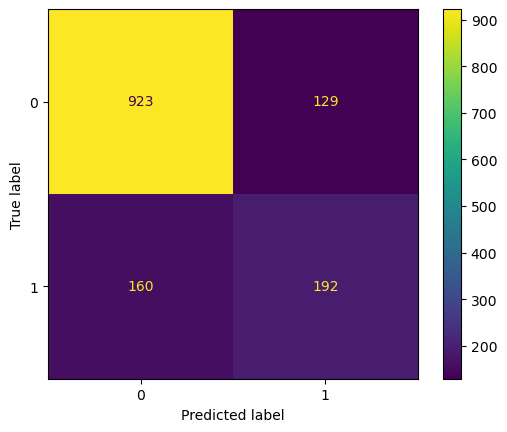

In [255]:
disp.plot()

# Feature importance (Logistic Regression Coefficients)

In [258]:
feature_importance=pd.DataFrame({
    "feature":X.columns,
    "Coefficient":best_lr.coef_[0]
})

In [260]:
feature_importance=feature_importance.sort_values(by="Coefficient",ascending=False)
print(feature_importance)

                                  feature  Coefficient
16            InternetService_Fiber optic     0.696398
14         MultipleLines_No phone service     0.544168
23         PaymentMethod_Electronic check     0.319515
10                        StreamingMovies     0.279843
15                      MultipleLines_Yes     0.276030
11                       PaperlessBilling     0.266514
1                           SeniorCitizen     0.248312
9                             StreamingTV     0.223910
2                                 Partner     0.031350
13                           TotalCharges     0.000316
12                         MonthlyCharges    -0.000831
0                                  gender    -0.021441
17                     InternetService_No    -0.029994
7                        DeviceProtection    -0.051196
4                                  tenure    -0.059148
24             PaymentMethod_Mailed check    -0.065718
22  PaymentMethod_Credit card (automatic)    -0.072797
5         

In [262]:
import pickle

with open("churn_model.pkl", "wb") as f:
    pickle.dump(best_lr, f)